**Monitoramento de Saúde de Astronautas no Espaço**

In [ ]:
# Instalando as bibliotecas no servidor do Google Colab
# Passo 0: Preparação do Ambiente
# No Google Colab, precisamos instalar a biblioteca scikit-fuzzy.
# Se estiver rodando localmente no Jupyter e já tiver instalado, pode pular esta célula.
#(Nota: O networkx específico é um truque para evitar warnings visuais chatos nas versões mais recentes do scikit-fuzzy no Colab).

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 27.4 MB/s eta 0:00:00
  Attempting uninstall: networkx
    Found existing installation: networkx 3.6.1
    Uninstalling networkx-3.6.1:
      Successfully uninstalled networkx-3.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
spopt 0.7.0 requires networkx>=3.2, but you have networkx 2.8.8 which is incompatible.
scikit-image 0.25.2 requires networkx>=3.0, but you have networkx 2.8.8 which is incompatible.
momepy 0.11.0 requires networkx>=3.2, but you have networkx 2.8.8 which is incompatible.
mapclassify 2.10.0 requires networkx>=3.2, but you have networkx 2.8.8 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 19.3 MB/s eta 0:00:00


### Passo 1: Fuzzificação e Variáveis Linguísticas
A fuzzificação transforma valores físicos (como a temperatura exata em graus) em graus de pertinência em conjuntos fuzzy. Uma variável linguística sistematiza o uso de palavras e sentenças.

Vamos mapear as medições dos sensores em faixas de pertinência.

In [ ]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# Definindo o Universo de Discurso (limites numéricos)
# Temperatura corporal (°C) variando de 35 a 41
temperatura = ctrl.Antecedent(np.arange(35, 42, 1), 'temperatura')

# Frequência Cardíaca (bpm) variando de 40 a 140
batimentos = ctrl.Antecedent(np.arange(40, 141, 1), 'batimentos')

# Risco de Saúde (%) variando de 0 a 100 - Este é o nosso Consequente
risco_saude = ctrl.Consequent(np.arange(0, 101, 1), 'risco_saude')

# Criando as Funções de Pertinência (Triangulares)
temperatura['baixa'] = fuzz.trimf(temperatura.universe, [35, 35, 37])
temperatura['normal'] = fuzz.trimf(temperatura.universe, [36, 37, 38])
temperatura['alta'] = fuzz.trimf(temperatura.universe, [37, 41, 41])

batimentos['baixos'] = fuzz.trimf(batimentos.universe, [40, 40, 70])
batimentos['normais'] = fuzz.trimf(batimentos.universe, [60, 80, 100])
batimentos['altos'] = fuzz.trimf(batimentos.universe, [90, 140, 140])

risco_saude['seguro'] = fuzz.trimf(risco_saude.universe, [0, 0, 50])
risco_saude['alerta'] = fuzz.trimf(risco_saude.universe, [20, 50, 80])
risco_saude['critico'] = fuzz.trimf(risco_saude.universe, [50, 100, 100])

#### Visualizando os Conjuntos Nebulosos
Uma das grandes vantagens dos notebooks é podermos ver a matemática acontecendo. Vamos visualizar as funções que mapeiam cada elemento em um número real no intervalo [0,1].

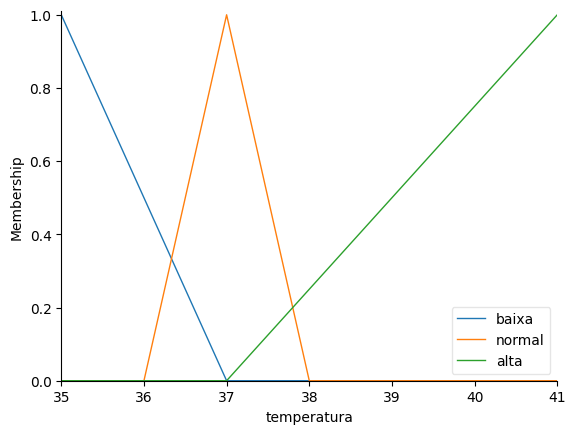

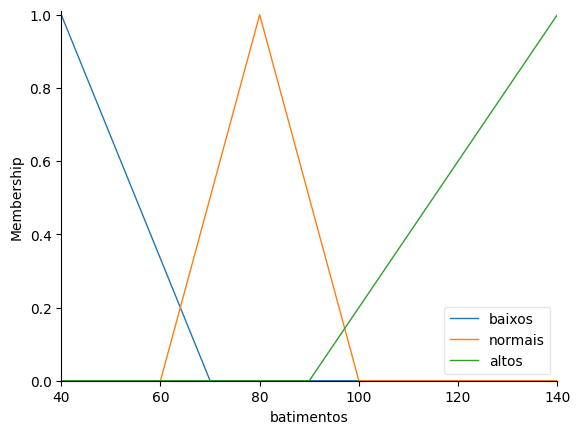

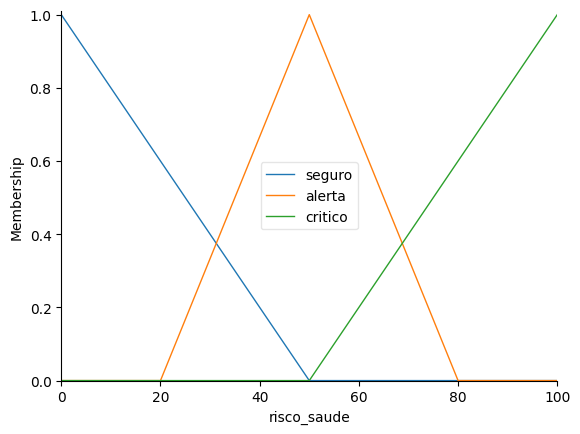

In [ ]:
# O método .view() gera o gráfico da função de pertinência
temperatura.view()
batimentos.view()
risco_saude.view()

### Passo 2: Base de Regras (Inferência Multivariada)
Diferente de sistemas convencionais que disparam alarmes para um único limite, a lógica fuzzy verifica a combinação de múltiplos dados simultaneamente.

Vamos aplicar regras IF-THEN baseadas em conhecimento especialista

In [ ]:
# Regras baseadas nos cenários de monitoramento:
# C0: Temp Normal E Batimentos Normais -> Risco Seguro
regra_c0 = ctrl.Rule(temperatura['normal'] & batimentos['normais'], risco_saude['seguro'])

# C4: Temp Baixa -> Risco Alerta (Hipotermia)
regra_c4 = ctrl.Rule(temperatura['baixa'], risco_saude['alerta'])

# C26: Temp Alta E Batimentos Altos -> Risco Crítico
regra_c26 = ctrl.Rule(temperatura['alta'] & batimentos['altos'], risco_saude['critico'])

# Adicionando as regras ao Controlador
sistema_controle = ctrl.ControlSystem([regra_c0, regra_c4, regra_c26])
simulador = ctrl.ControlSystemSimulation(sistema_controle)

A defuzzificação converte a decisão lógica de volta para um valor numérico que a máquina pode executar (ou que os médicos na Terra possam interpretar)

--- Lendo sensores do Astronauta ---

Risco de Saúde Calculado pelo Sistema: 80.56%


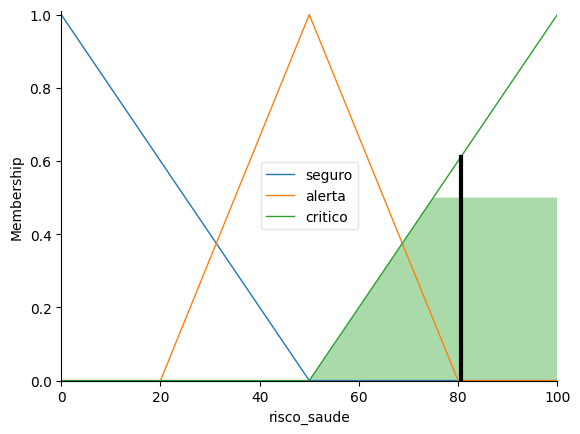

In [ ]:
# Inserindo dados "crus" recebidos dos sensores do traje espacial
print("--- Lendo sensores do Astronauta ---")
simulador.input['temperatura'] = 39.5  # Febre
simulador.input['batimentos'] = 115    # Taquicardia

# Computando a lógica fuzzy
simulador.compute()

# Resultado Defuzzificado
resultado = simulador.output['risco_saude']
print(f"\nRisco de Saúde Calculado pelo Sistema: {resultado:.2f}%")

# Visualizando o resultado no gráfico do consequente
risco_saude.view(sim=simulador)

# **Sequência de Testes Estatísticos**

# Prática: Testes de Suposição e Hipóteses com Python
## Estudo de Caso: Avaliação de Medicação Espacial

Nesta prática, vamos simular que a equipe médica testou duas medicações diferentes para estabilizar os batimentos cardíacos dos astronautas. Nosso objetivo é comprovar estatisticamente se essas medicações realmente funcionam em comparação a um grupo de controle (sem medicação).

### A Regra de Ouro do p-valor ($p$-value)
Na estatística, assumimos uma "Hipótese Nula" ($H_0$), que geralmente significa "nada está acontecendo" ou "não há diferença".
Adotamos um nível de significância padrão de **5% (0.05)**.
* Se o **p-valor < 0.05**: Temos evidências fortes para **rejeitar $H_0$**. (Algo diferente está acontecendo!)
* Se o **p-valor > 0.05**: **Falhamos em rejeitar $H_0$**. (Continuamos assumindo que nada mudou).

In [ ]:
import numpy as np
from scipy import stats

# Gerando dados sintéticos: Frequência cardíaca (bpm) de 3 grupos de astronautas
np.random.seed(42) # Mantém os resultados iguais para toda a turma

grupo_controle = np.random.normal(loc=75, scale=5, size=30)  # Sem medicação
grupo_med_A = np.random.normal(loc=72, scale=5, size=30)     # Recebeu Medicação A
grupo_med_B = np.random.normal(loc=65, scale=4, size=30)     # Recebeu Medicação B

print("Dados gerados com sucesso!")

Dados gerados com sucesso!


### Parte 1: O "Checklist" de Segurança (Testes de Suposição)
Antes de fazermos as perguntas de negócio (ex: "O remédio funciona?"), precisamos testar nossas **suposições**. Testes estatísticos paramétricos exigem que os dados tenham certos formatos. Se ignorarmos isso, nossos resultados serão inválidos.

#### 1.1 Teste de Normalidade (Shapiro-Wilk)
* **Objetivo:** Verificar se os dados seguem o formato de uma curva normal (sino).
* **$H_0$:** A amostra provém de uma distribuição normal.

In [ ]:
stat_sw, p_sw = stats.shapiro(grupo_controle)

print("--- 1. TESTE DE NORMALIDADE (Shapiro-Wilk) ---")
print(f"p-valor: {p_sw:.4f}")

if p_sw > 0.05:
    print("Conclusão: Falha em rejeitar H0. Os dados parecem ser NORMAIS.")
else:
    print("Conclusão: Rejeita H0. Os dados NÃO parecem ser normais.")

--- 1. TESTE DE NORMALIDADE (Shapiro-Wilk) ---
p-valor: 0.6868
Conclusão: Falha em rejeitar H0. Os dados parecem ser NORMAIS.


#### 1.2 Teste de Homogeneidade de Variâncias (Levene)
* **Objetivo:** Verificar se a "dispersão" dos dados é parecida entre os grupos. Testes como a ANOVA exigem variâncias semelhantes.
* **$H_0$:** As variâncias populacionais são iguais (homogêneas).

In [ ]:
stat_lev, p_lev = stats.levene(grupo_controle, grupo_med_A, grupo_med_B)

print("--- 2. TESTE DE VARIÂNCIAS (Levene) ---")
print(f"p-valor: {p_lev:.4f}")

if p_lev > 0.05:
    print("Conclusão: Falha em rejeitar H0. As variâncias são HOMOGÊNEAS.")
else:
    print("Conclusão: Rejeita H0. As variâncias NÃO são homogêneas.")

--- 2. TESTE DE VARIÂNCIAS (Levene) ---
p-valor: 0.5394
Conclusão: Falha em rejeitar H0. As variâncias são HOMOGÊNEAS.


### Parte 2: Respondendo à Pergunta de Pesquisa (Testes de Hipótese)
Agora que o checklist de segurança passou, podemos aplicar os testes paramétricos para descobrir se as medicações realmente alteraram os batimentos cardíacos.

#### 2.1 Teste T de Student (Para 2 Grupos)
* **Objetivo:** Comparar se a média de **dois** grupos independentes é estatisticamente igual.
* **$H_0$:** As médias do Grupo Controle e da Medicação A são IGUAIS.

In [ ]:
stat_t, p_t = stats.ttest_ind(grupo_controle, grupo_med_A)

print("--- 3. TESTE T (Controle vs Medicação A) ---")
print(f"p-valor: {p_t:.4f}")

if p_t > 0.05:
    print("Conclusão: Falha em rejeitar H0. NÃO HÁ diferença significativa na eficácia.")
else:
    print("Conclusão: Rejeita H0. HÁ uma diferença significativa entre os grupos.")

--- 3. TESTE T (Controle vs Medicação A) ---
p-valor: 0.0280
Conclusão: Rejeita H0. HÁ uma diferença significativa entre os grupos.


#### 2.2 ANOVA - Análise de Variância (Para 3+ Grupos)
* **Objetivo:** Comparar as médias de **três ou mais** grupos simultaneamente.
* **$H_0$:** Todas as médias dos grupos são IGUAIS.

In [ ]:
stat_anova, p_anova = stats.f_oneway(grupo_controle, grupo_med_A, grupo_med_B)

print("--- 4. ANOVA (Comparando os 3 grupos) ---")
print(f"p-valor: {p_anova:.4f}")

if p_anova > 0.05:
    print("Conclusão: Falha em rejeitar H0. Todas as médias são iguais.")
else:
    print("Conclusão: Rejeita H0. Pelo menos UMA das medicações tem efeito diferente das demais.")

--- 4. ANOVA (Comparando os 3 grupos) ---
p-valor: 0.0000
Conclusão: Rejeita H0. Pelo menos UMA das medicações tem efeito diferente das demais.


# **Entendendo a simulação com teste de hipótese usando fuzzy:** O que fizemos e por que fizemos?
Nesta prática, nós simulamos o trabalho de um Cientista de Dados analisando um experimento médico. Nossa missão era descobrir se duas novas medicações realmente funcionam para estabilizar os batimentos cardíacos de astronautas no espaço, ou se qualquer melhora foi apenas obra do acaso (sorte).

Para chegar à resposta, nosso código seguiu uma jornada lógica de três etapas:

1. A Criação do Cenário (Geração dos Dados)
No mundo real, nós receberíamos esses dados de sensores ou planilhas de hospitais. Como estamos em um ambiente de simulação, usamos a biblioteca numpy para criar "pacientes virtuais" divididos em três grupos de 30 pessoas:

Grupo Controle: Não tomou remédio (batimentos em torno de 75 bpm).

Grupo Medicação A: Tomou o remédio A.

Grupo Medicação B: Tomou o remédio B.

2. A Verificação das Regras do Jogo (Testes de Suposição)
A estatística é uma ferramenta poderosa, mas exige que certas regras sejam cumpridas. Não podemos simplesmente jogar os dados em uma fórmula complexa sem antes verificar o formato deles. Esses primeiros testes são o nosso "checklist de segurança":

Teste de Shapiro-Wilk (Normalidade): Ele verifica se os nossos dados se comportam como uma "curva de sino" padrão . Se os dados forem muito tortos ou cheios de anomalias, as fórmulas seguintes vão dar resultados mentirosos. Se o p-valor for maior que 0.05, os dados são "normais" e podemos prosseguir.

Teste de Levene (Variâncias): Ele confere se a "bagunça" (a variação dos batimentos) é parecida em todos os grupos. Se um grupo tem batimentos que variam de 60 a 90, e outro varia só de 70 a 72, as variâncias são muito diferentes e a comparação se torna injusta.

3. O Veredito Final (Para que servem os Testes Estatísticos Finais?)
É aqui que respondemos à grande pergunta: "O remédio funciona mesmo?". Olhar apenas para a média matemática não é suficiente, porque a diferença entre 75 bpm e 72 bpm pode ter sido pura coincidência da amostra.

Os testes finais servem para nos dar uma prova matemática de que a medicação causou um impacto real e significativo. Nós sempre buscamos um p-valor menor que 0.05 (5%) — esse é o nosso sinal verde para dizer que o remédio funciona.

Para que serve o Teste T de Student?
Ele é o teste de "combate 1 contra 1". Ele serve para comparar exatamente dois grupos. No nosso código, usamos o Teste T para comparar o Grupo Controle diretamente com a Medicação A. Ele calcula se a diferença entre as médias desses dois grupos é grande o suficiente para descartarmos a coincidência.

Para que serve a ANOVA (Análise de Variância)?
Ela é o nosso teste no estilo "Battle Royale". Se temos três ou mais grupos (Controle, Medicação A e Medicação B), não podemos ficar fazendo o Teste T de par em par, pois isso aumenta a chance de erros matemáticos. A ANOVA analisa todos os grupos de uma só vez. Se o p-valor da ANOVA for menor que 0.05, ela nos dá um alerta: "Atenção! Pelo menos uma dessas medicações está causando um efeito muito diferente das outras".

Em resumo: O computador e a linguagem Python fazem as contas pesadas em frações de segundo, mas é você, analisando o p-valor final, quem toma a decisão crítica de aprovar ou descartar uma medicação.